In [2]:
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.io.fits as fits

# Load data image and header

In [13]:
data_dir = os.getcwd()
files_roll1 = [f for f in os.listdir(data_dir) if f.startswith("host_star_image_roll1")]
files_roll2 = [f for f in os.listdir(data_dir) if f.startswith("host_star_image_roll2")]
print(files_roll1)
print(files_roll2)

roll1 = []
for file in files_roll1:
    roll1.append(fits.getdata(file))
roll1 = np.array(roll1)

roll2 = []
for file in files_roll2:
    roll2.append(fits.getdata(file))
roll2 = np.array(roll2)

['host_star_image_roll1_0.fits']
['host_star_image_roll2_0.fits']


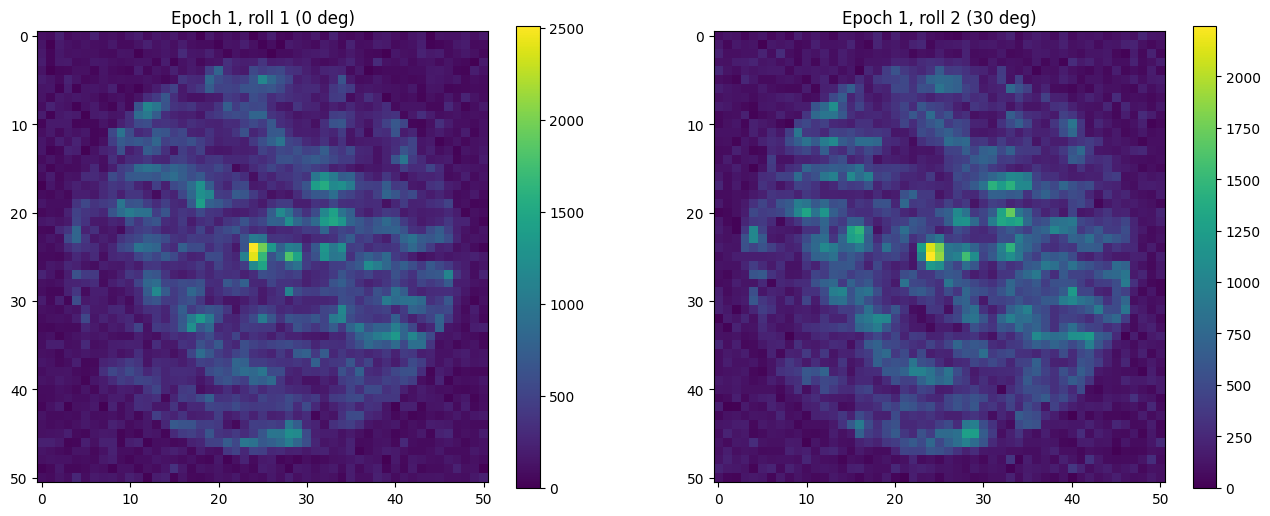

In [14]:
coadd_roll1 = np.mean(roll1, axis = 0)
coadd_roll2 = np.mean(roll2, axis = 0)

plt.figure(figsize=(16,6))

plt.subplot(121)
plt.imshow(coadd_roll1)
plt.title('Epoch 1, roll 1 (0 deg)')
plt.colorbar()

plt.subplot(122)
plt.title('Epoch 1, roll 2 (30 deg)')
plt.imshow(coadd_roll2)
plt.colorbar()

# Roll subtraction and roll combination

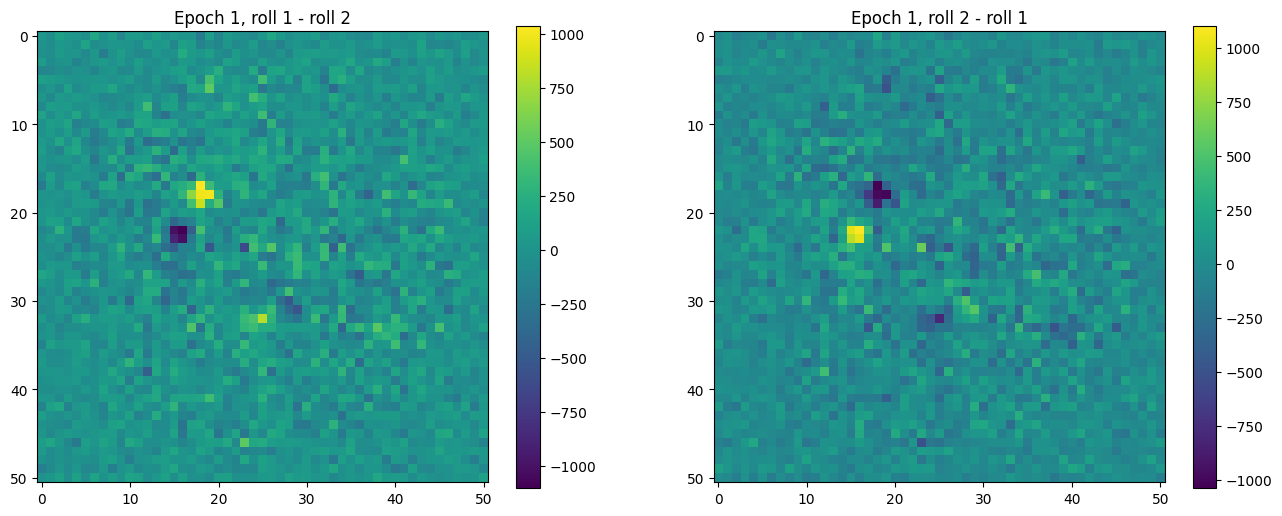

In [15]:
diff1 = coadd_roll1 - coadd_roll2
diff2 = coadd_roll2 - coadd_roll1

plt.figure(figsize=(16,6))

plt.subplot(121)
plt.imshow(diff1)
plt.title('Epoch 1, roll 1 - roll 2')
plt.colorbar()

plt.subplot(122)
plt.title('Epoch 1, roll 2 - roll 1')
plt.imshow(diff2)
plt.colorbar()

In [16]:
import skimage.transform
scistar_coadd_ep1_rolls = [0, 30]
imgwidth = diff2.shape[0]
derot_diff_2 = skimage.transform.rotate(image = diff2,
                                        angle = -scistar_coadd_ep1_rolls[1],
                                        center = (imgwidth // 2, imgwidth // 2),
                                        order = 3, cval = np.nan)
derot_sum = diff1 + derot_diff_2

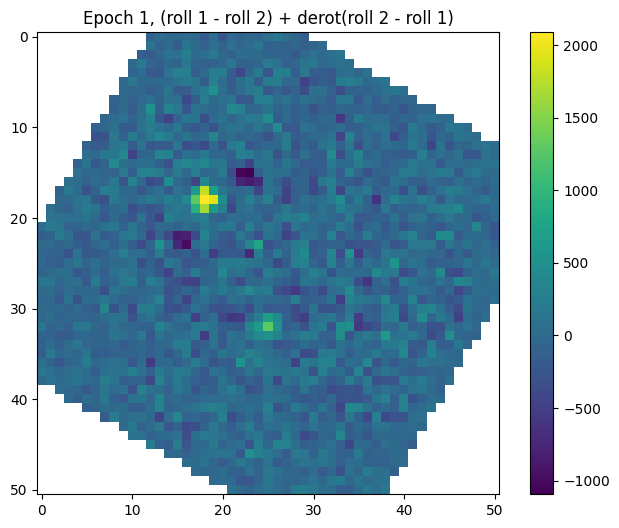

In [17]:
plt.figure(figsize=(8,6))

plt.imshow(derot_sum)

plt.title('Epoch 1, (roll 1 - roll 2) + derot(roll 2 - roll 1)')
plt.colorbar()

## Question 1: How would you estimate the signal-to-noise ratio of this source?